In [1]:
import numpy as np
from matplotlib import pyplot as plt

from evaluation_package import filetools as ft
from evaluation_package import daq_read as daq

In [2]:
# Specify the experiment type
experiment_type = "DAQ_read_sweep"

# Specify the subfolder list natively as a string path
subfolder = ""

# Load the experiment data
yaml_config, data_list = ft.load_experiment_data(experiment_type, subfolders=subfolder, print=True, date_key="2025-09-17-11-36-27")
data = data_list[0]  # Take first run

The data of the following experiment is loaded: DAQ_read_sweep_2025-09-17-11-36-27.yaml


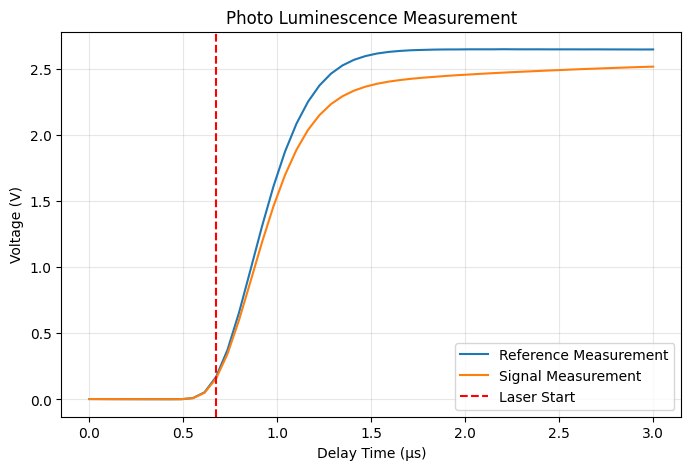

In [3]:
# Calculate core parameters
delay_times = daq.calc_delay_times(yaml_config)
t0_laser = daq.laser_starting_time(yaml_config, data)

plt.figure(figsize=(8, 5))

# Plot Reference & Signal Measurements
plt.plot(delay_times, data[0].flatten() / 100, label="Reference Measurement")
plt.plot(delay_times, data[1].flatten() / 100, label="Signal Measurement")

# Mark Laser Start
plt.axvline(x=t0_laser, color='r', linestyle='--', label='Laser Start')

plt.title("Photo Luminescence Measurement")
plt.xlabel("Delay Time (\u03bcs)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


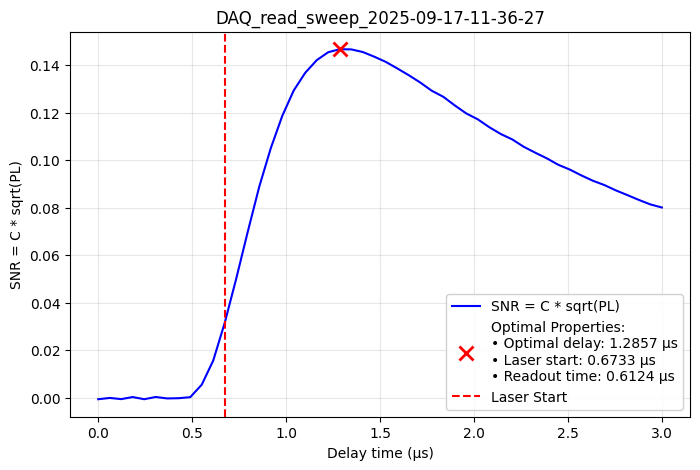

In [4]:
# Evaluate SNR properties
snr = daq.calc_snr(yaml_config, data)
optimal_delay = daq.find_optimal_delay(yaml_config, data)
readout_time = optimal_delay - t0_laser
id_optimal = np.argmax(snr)

plt.figure(figsize=(8, 5))

# Create multiline string for optimal stats
label_text = (
    f"Optimal Properties:\n"
    f"\u2022 Optimal delay: {optimal_delay:.4f} \u03bcs\n"
    f"\u2022 Laser start: {t0_laser:.4f} \u03bcs\n"
    f"\u2022 Readout time: {readout_time:.4f} \u03bcs"
)

# Plot SNR Curve and mark the optimal point
plt.plot(delay_times, snr, color="blue", label="SNR = C * sqrt(PL)")
plt.plot(optimal_delay, snr[id_optimal], 'rx', markersize=10, markeredgewidth=2, label=label_text)
plt.axvline(x=t0_laser, color='r', linestyle='--', label='Laser Start')

plt.title(yaml_config["filename"])
plt.xlabel("Delay time (\u03bcs)")
plt.ylabel("SNR = C * sqrt(PL)")
plt.legend(framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()
